# Hierarchical Clustering
## A Complete, Practical Guide from First Principles to Production

Hierarchical clustering is one of the most interpretable clustering algorithms ever built.  
Unlike K-Means, you never have to commit to a number of clusters upfront — the algorithm builds a **full tree of all possible groupings** and you decide where to cut it.

This notebook covers:
- The core algorithm (agglomerative, bottom-up)
- Every linkage method with visual intuition
- Dendrograms — how to read and cut them
- Distance metrics and when to use each
- Practical implementation with `scipy` and `sklearn`
- Full pipeline on the Iris dataset and customer data
- Evaluation metrics for clustering quality
- When hierarchical beats K-Means and when it doesn't


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist, squareform, euclidean
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs, load_iris, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})
sns.set_palette("tab10")

print("All imports loaded.")


All imports loaded.


## 1. The Core Idea

Agglomerative hierarchical clustering follows a simple greedy strategy:

1. Start: every data point is its own cluster → N clusters
2. Find the two **closest** clusters
3. Merge them into one
4. Repeat steps 2–3 until only 1 cluster remains

The full history of merges forms a binary tree called a **dendrogram**.  
The height of each merge encodes how dissimilar the merged clusters were.

The algorithm never revisits a decision — merges are permanent.  
This is both its strength (interpretable tree) and its weakness (no correction for early mistakes).


In [7]:
# Trace every merge step manually on 5 points

np.random.seed(7)
X_tiny = np.array([[1.0, 2.0],
                   [1.5, 1.8],
                   [5.0, 8.0],
                   [8.0, 8.0],
                   [1.0, 0.6]])
names = ['A', 'B', 'C', 'D', 'E']

# compute full pairwise distance matrix
dist_matrix = squareform(pdist(X_tiny, metric='euclidean'))
df_dist = pd.DataFrame(np.round(dist_matrix, 2), index=names, columns=names)

print("Pairwise Euclidean Distance Matrix:")
print(df_dist.to_string())
print()
print("Smallest distance:", df_dist.replace(0, np.inf).min().min(),
      "→ closest pair is A & B")


Pairwise Euclidean Distance Matrix:
      A     B     C      D      E
A  0.00  0.54  7.21   9.22   1.40
B  0.54  0.00  7.12   8.98   1.30
C  7.21  7.12  0.00   3.00   8.41
D  9.22  8.98  3.00   0.00  10.19
E  1.40  1.30  8.41  10.19   0.00

Smallest distance: 0.54 → closest pair is A & B


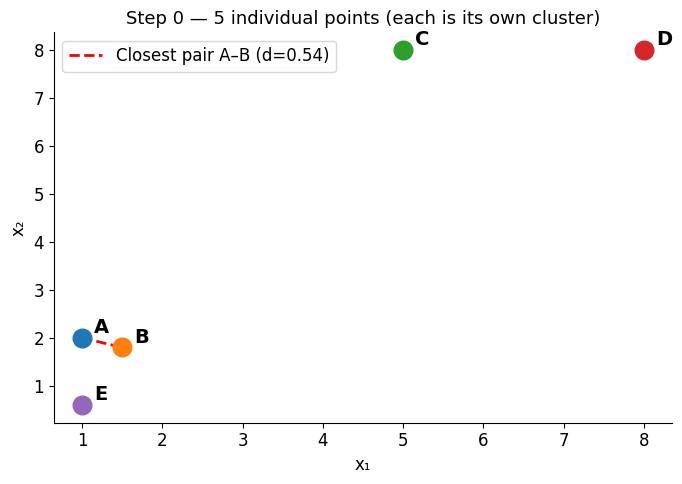

In [8]:
# Visualise the 5 points + annotate distances

fig, ax = plt.subplots(figsize=(7, 5))
for i, (x, y) in enumerate(X_tiny):
    ax.scatter(x, y, s=180, zorder=5)
    ax.text(x + 0.15, y + 0.1, names[i], fontsize=14, fontweight='bold')

# draw line between A and B (closest pair)
ax.plot([X_tiny[0,0], X_tiny[1,0]], [X_tiny[0,1], X_tiny[1,1]],
        'r--', lw=2, label=f'Closest pair A–B (d={dist_matrix[0,1]:.2f})')
ax.set_title("Step 0 — 5 individual points (each is its own cluster)", fontsize=13)
ax.legend()
ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
plt.tight_layout()
plt.show()


## 2. Linkage Criteria — The Heart of Hierarchical Clustering

When merging clusters, the key question is: **how do you measure the distance between two clusters?**  
A cluster is a *set* of points, not a single point — so we need a rule.

| Linkage | Distance Definition | Behaviour |
|---------|-------------------|-----------|
| **Single** | min distance between any pair across clusters | Chains easily, finds elongated shapes |
| **Complete** | max distance between any pair | Compact, spherical clusters |
| **Average** | mean of all pairwise distances | Balance between single & complete |
| **Ward** | minimize within-cluster variance | Best for compact, equal-size clusters |
| **Centroid** | distance between cluster centroids | Inversion can occur |

Ward linkage is almost always the best starting point for tabular data.


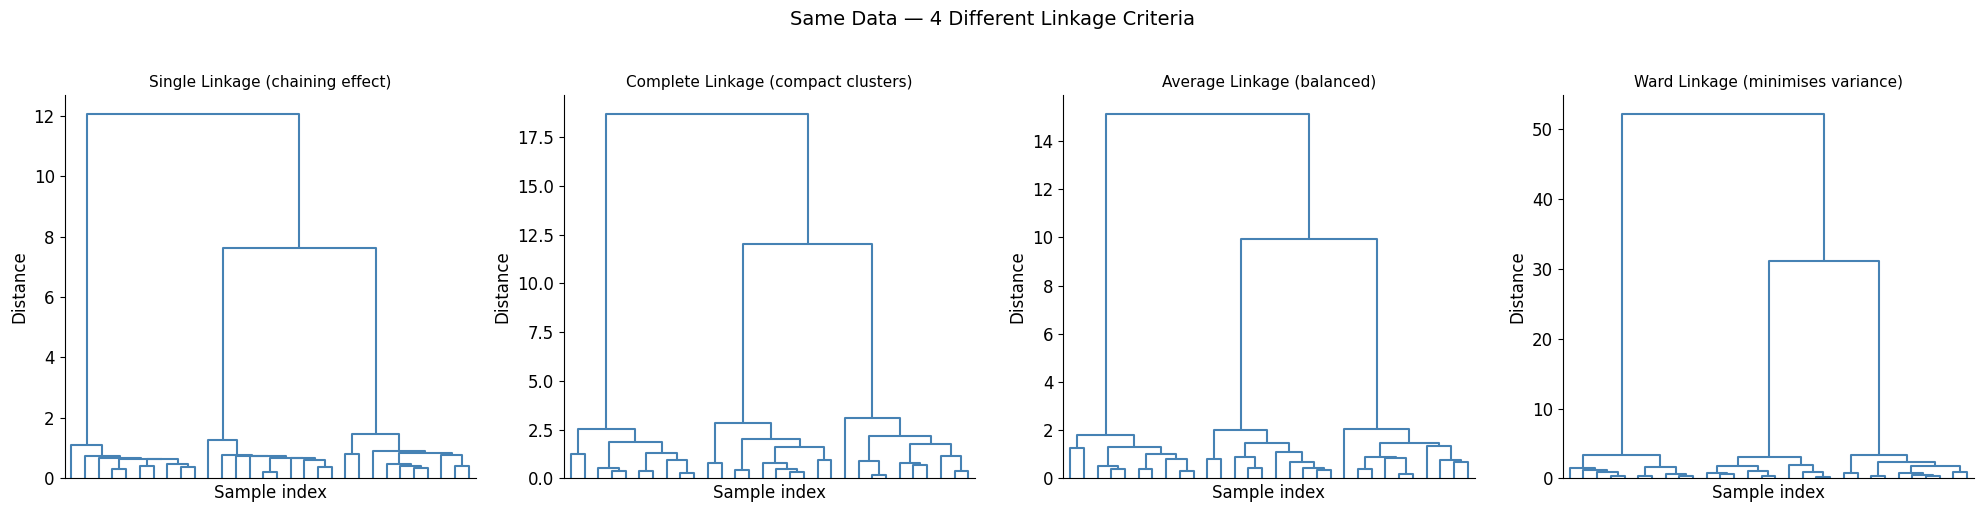

In [9]:
# Re-run the demo with fixed title strings (no invalid multiline literals)

np.random.seed(42)
X_demo, _ = make_blobs(n_samples=30, centers=3, cluster_std=0.8)

methods = ['single', 'complete', 'average', 'ward']
titles  = [
    'Single Linkage (chaining effect)',
    'Complete Linkage (compact clusters)',
    'Average Linkage (balanced)',
    'Ward Linkage (minimises variance)'
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, method, title in zip(axes, methods, titles):
    Z = linkage(X_demo, method=method)
    dendrogram(Z, ax=ax, color_threshold=0, above_threshold_color='steelblue',
               no_labels=True, link_color_func=lambda k: 'steelblue')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Sample index")
    ax.set_ylabel("Distance")

fig.suptitle("Same Data — 4 Different Linkage Criteria", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Reading a Dendrogram

A dendrogram is a binary tree where:
- **Leaves** (bottom) = individual data points
- **Internal nodes** = merge events
- **Height of a merge** = distance (dissimilarity) at which the merge happened
- **Horizontal line you draw** = the number of clusters you want

To get K clusters: draw a horizontal line such that it crosses exactly K vertical lines.

The **longest vertical gap** in the dendrogram is the most natural cut — it means those clusters are far apart.


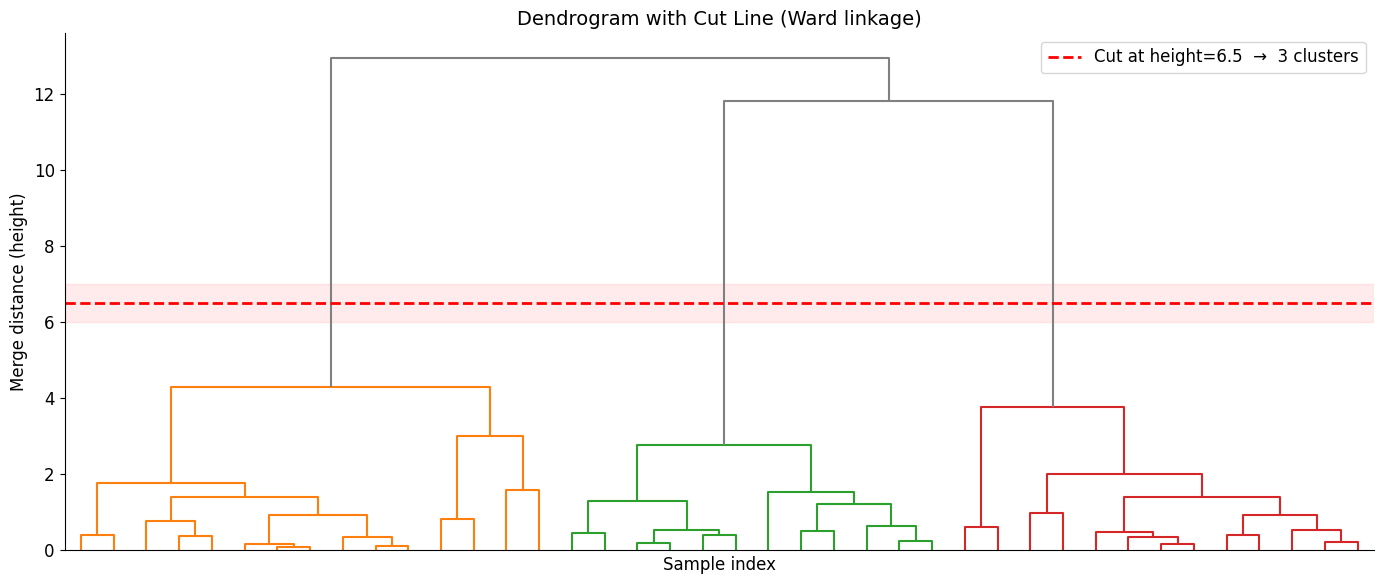

In [10]:
# A well-annotated dendrogram showing how to cut it

np.random.seed(0)
X_cut, y_true = make_blobs(n_samples=40, centers=3, cluster_std=0.7)
Z_ward = linkage(X_cut, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
ddata = dendrogram(Z_ward, ax=ax, color_threshold=6.5,
                   above_threshold_color='gray', no_labels=True)

# draw cut line
cut_height = 6.5
ax.axhline(y=cut_height, color='red', linestyle='--', lw=2,
           label=f'Cut at height={cut_height}  →  3 clusters')
ax.axhspan(cut_height - 0.5, cut_height + 0.5, alpha=0.08, color='red')

ax.set_title("Dendrogram with Cut Line (Ward linkage)", fontsize=14)
ax.set_xlabel("Sample index")
ax.set_ylabel("Merge distance (height)")
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()


In [11]:
# Confirm: extract cluster labels from the cut

labels_cut = fcluster(Z_ward, t=6.5, criterion='distance')
print("Cluster labels:", labels_cut)
print("Cluster sizes:", pd.Series(labels_cut).value_counts().sort_index().to_dict())
print("Silhouette score:", round(silhouette_score(X_cut, labels_cut), 4))


Cluster labels: [1 3 2 1 1 3 1 3 2 1 3 3 3 1 1 2 2 3 3 3 1 2 2 2 2 1 2 1 1 2 2 1 1 1 3 3 3
 2 1 3]
Cluster sizes: {1: 15, 2: 12, 3: 13}
Silhouette score: 0.5917


## 4. Distance Metrics

The choice of distance metric changes the shape of clusters the algorithm can detect.

| Metric | Formula | Best For |
|--------|---------|---------|
| **Euclidean** | √Σ(aᵢ−bᵢ)² | Continuous, normalised data |
| **Manhattan** | Σ\|aᵢ−bᵢ\| | Robust to outliers |
| **Cosine** | 1 − (a·b)/(‖a‖‖b‖) | Text, high-dimensional |
| **Correlation** | 1 − corr(a, b) | Time-series, gene expression |

Euclidean + Ward is the default powerhouse combo for most tabular ML tasks.


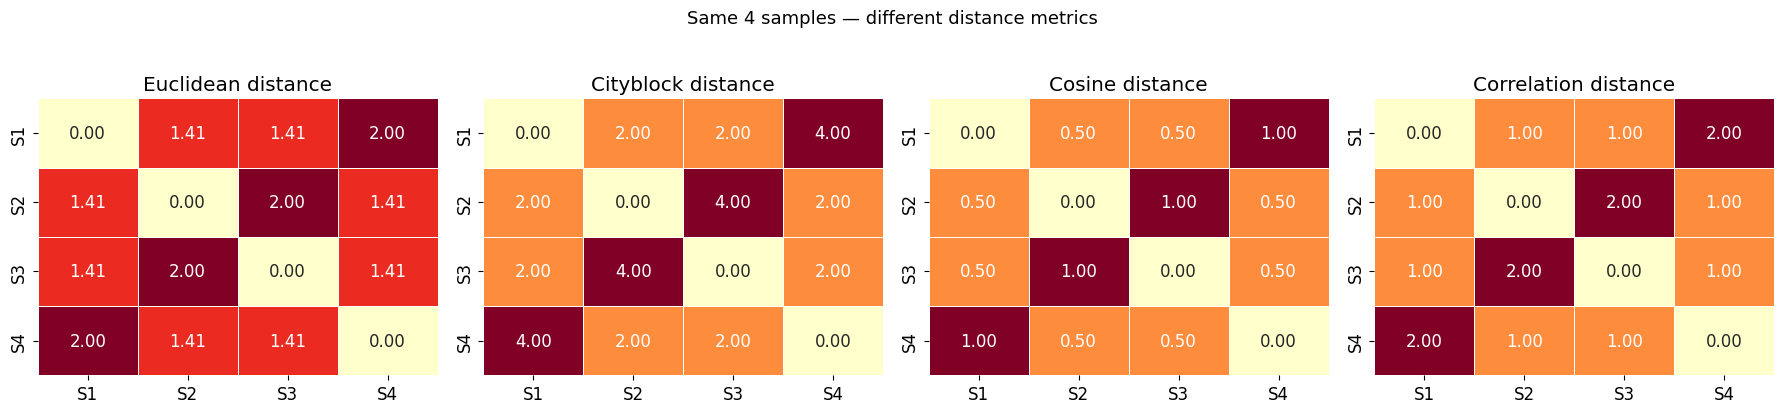

In [12]:
# Show how metric choice changes the distance matrix — on 4 sample vectors

samples = np.array([[1,0,0,1],
                    [1,1,0,0],
                    [0,0,1,1],
                    [0,1,1,0]], dtype=float)

metrics = ['euclidean', 'cityblock', 'cosine', 'correlation']
labels_s = ['S1','S2','S3','S4']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, metric in zip(axes, metrics):
    D = squareform(pdist(samples, metric=metric))
    sns.heatmap(D, annot=True, fmt='.2f', ax=ax, cmap='YlOrRd',
                xticklabels=labels_s, yticklabels=labels_s,
                cbar=False, linewidths=0.5)
    ax.set_title(f'{metric.capitalize()} distance')

plt.suptitle("Same 4 samples — different distance metrics", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()


## 5. Step-by-Step: Single Linkage on a Small Dataset

Let's manually reproduce what scipy does under the hood for single linkage.
This cements the algorithm in your memory forever.


In [13]:
# Manual single-linkage walkthrough

def single_linkage_trace(X, names):
    n = len(X)
    # init: each point is its own cluster
    clusters = {i: [names[i]] for i in range(n)}
    dist = squareform(pdist(X, 'euclidean'))
    np.fill_diagonal(dist, np.inf)

    step = 0
    active = list(range(n))
    while len(active) > 1:
        # find closest active pair
        min_d = np.inf
        pair = (-1, -1)
        for i in active:
            for j in active:
                if i < j and dist[i, j] < min_d:
                    min_d = dist[i, j]
                    pair = (i, j)
        i, j = pair
        step += 1
        merged = clusters[i] + clusters[j]
        print(f"Step {step}: merge {clusters[i]} + {clusters[j]}  →  distance = {min_d:.3f}")
        clusters[i] = merged
        del clusters[j]
        active.remove(j)
        # update distances: single linkage = min
        for k in active:
            if k != i:
                dist[i, k] = dist[k, i] = min(dist[i, k], dist[j, k])
    print("Done! Final cluster:", clusters[active[0]])

single_linkage_trace(X_tiny, names)


Step 1: merge ['A'] + ['B']  →  distance = 0.539
Step 2: merge ['A', 'B'] + ['E']  →  distance = 1.300
Step 3: merge ['C'] + ['D']  →  distance = 3.000
Step 4: merge ['A', 'B', 'E'] + ['C', 'D']  →  distance = 7.120
Done! Final cluster: ['A', 'B', 'E', 'C', 'D']


## 6. scipy Linkage Matrix — Decoding the Z Array

`scipy.cluster.hierarchy.linkage()` returns a matrix Z with shape (n-1, 4):

| Column | Meaning |
|--------|---------|
| 0 | Index of cluster 1 in the merge |
| 1 | Index of cluster 2 in the merge |
| 2 | Distance at which they merged |
| 3 | Number of original points in the new cluster |

New cluster indices start at n (original indices are 0 to n-1).


In [14]:
# Decode the linkage matrix for our tiny 5-point dataset

Z_tiny = linkage(X_tiny, method='single')
n = len(X_tiny)

print(f"Original points: 0={names[0]}, 1={names[1]}, 2={names[2]}, 3={names[3]}, 4={names[4]}")
print(f"New cluster IDs start at {n}")
print()
print(f"{'Step':>4}  {'Cluster1':>9}  {'Cluster2':>9}  {'Distance':>10}  {'NewSize':>8}")
print("-" * 50)
for step, row in enumerate(Z_tiny):
    c1, c2, dist_val, size = int(row[0]), int(row[1]), row[2], int(row[3])
    label1 = names[c1] if c1 < n else f"[cluster {c1}]"
    label2 = names[c2] if c2 < n else f"[cluster {c2}]"
    print(f"{step+1:>4}  {label1:>9}  {label2:>9}  {dist_val:>10.4f}  {size:>8}")


Original points: 0=A, 1=B, 2=C, 3=D, 4=E
New cluster IDs start at 5

Step   Cluster1   Cluster2    Distance   NewSize
--------------------------------------------------
   1          A          B      0.5385         2
   2          E  [cluster 5]      1.3000         3
   3          C          D      3.0000         2
   4  [cluster 6]  [cluster 7]      7.1197         5


## 7. Choosing the Number of Clusters

Three practical methods:
1. **Dendrogram gap** — find the longest vertical stretch before the next merge
2. **Silhouette score** — measures how well each point fits its own cluster vs neighbours
3. **Inconsistency coefficient** — flags merges that are much larger than nearby merges


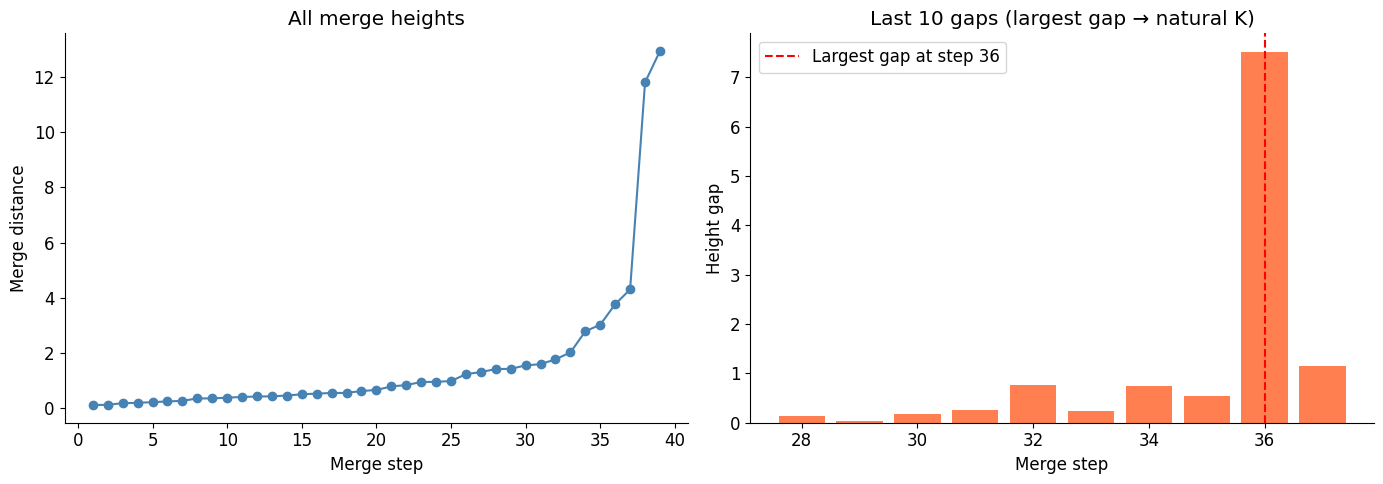

Largest gap at merge step 36 → suggests 3 clusters


In [15]:
# Method 1: largest gap in merge heights

Z_g = linkage(X_cut, method='ward')
merge_heights = Z_g[:, 2]
gaps = np.diff(merge_heights)

# last merges matter most — look at last 10
last_n = 10
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(merge_heights)+1), merge_heights, 'o-', color='steelblue')
axes[0].set_xlabel("Merge step")
axes[0].set_ylabel("Merge distance")
axes[0].set_title("All merge heights")

axes[1].bar(range(len(gaps)-last_n, len(gaps)), gaps[-last_n:], color='coral')
best_cut = np.argmax(gaps[-last_n:]) + len(gaps) - last_n
axes[1].axvline(x=best_cut, color='red', linestyle='--', label=f'Largest gap at step {best_cut}')
axes[1].set_xlabel("Merge step")
axes[1].set_ylabel("Height gap")
axes[1].set_title(f"Last {last_n} gaps (largest gap → natural K)")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Largest gap at merge step {best_cut} → suggests {len(X_cut) - best_cut - 1} clusters")


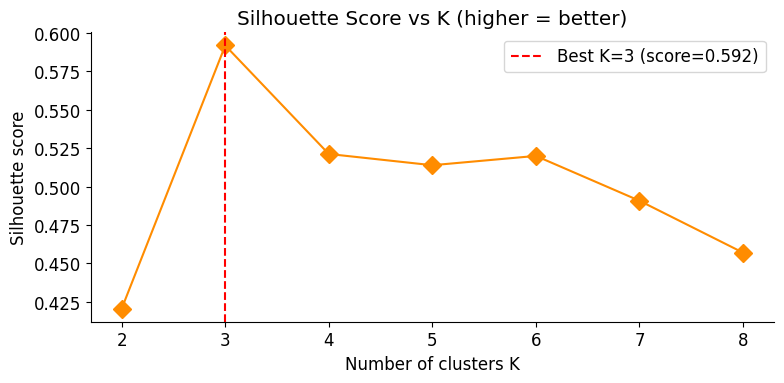

In [16]:
# Method 2: silhouette score sweep

scores = {}
for k in range(2, 9):
    labels_k = fcluster(Z_g, t=k, criterion='maxclust')
    scores[k] = silhouette_score(X_cut, labels_k)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(scores.keys()), list(scores.values()), 'D-', color='darkorange', ms=9)
best_k = max(scores, key=scores.get)
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k} (score={scores[best_k]:.3f})')
ax.set_xlabel("Number of clusters K")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette Score vs K (higher = better)")
ax.legend()
ax.set_xticks(range(2, 9))
plt.tight_layout()
plt.show()


## 8. Cophenetic Correlation Coefficient

The **cophenetic correlation** measures how faithfully the dendrogram preserves the original pairwise distances.  
A value > 0.75 is generally considered a good fit.

If the score is low, try a different linkage method or distance metric.


In [17]:
# Cophenetic correlation for all 4 linkage methods

X_eval, _ = make_blobs(n_samples=60, centers=4, cluster_std=1.0, random_state=1)

print(f"{'Linkage':>10}  {'Cophenetic Corr':>18}")
print("-" * 32)
for method in ['single', 'complete', 'average', 'ward']:
    Z_m = linkage(X_eval, method=method)
    c, _ = cophenet(Z_m, pdist(X_eval))
    print(f"{method:>10}  {c:>18.4f}")


   Linkage     Cophenetic Corr
--------------------------------
    single              0.9081
  complete              0.9209
   average              0.9266
      ward              0.9256


## 9. Agglomerative Clustering with scikit-learn

`sklearn.cluster.AgglomerativeClustering` is the production-ready API.  
It integrates with pipelines, supports connectivity constraints, and is faster for large datasets.


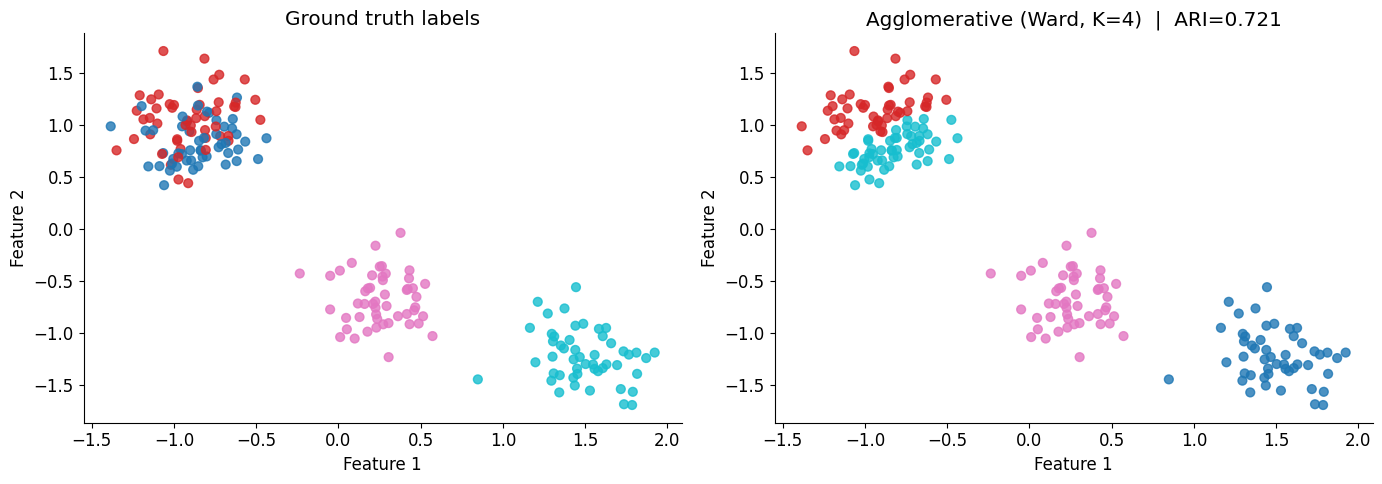

In [18]:
# sklearn API — clean and pipeline-friendly

from sklearn.cluster import AgglomerativeClustering

X_sk, y_sk = make_blobs(n_samples=200, centers=4, cluster_std=0.9, random_state=5)
X_sk = StandardScaler().fit_transform(X_sk)

agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_sk = agg.fit_predict(X_sk)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_sk[:, 0], X_sk[:, 1], c=y_sk, cmap='tab10', s=40, alpha=0.8)
axes[0].set_title("Ground truth labels")

axes[1].scatter(X_sk[:, 0], X_sk[:, 1], c=labels_sk, cmap='tab10', s=40, alpha=0.8)
axes[1].set_title(f"Agglomerative (Ward, K=4)  |  ARI={adjusted_rand_score(y_sk, labels_sk):.3f}")

for ax in axes:
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()


## 10. Connectivity Constraints

You can restrict which points can be merged by providing a **connectivity matrix**.  
This is useful when you know some points are structurally adjacent (e.g., grid data, geographic data).

Without connectivity, the algorithm is free to merge any pair.  
With connectivity, only connected points can merge — forcing spatially coherent clusters.


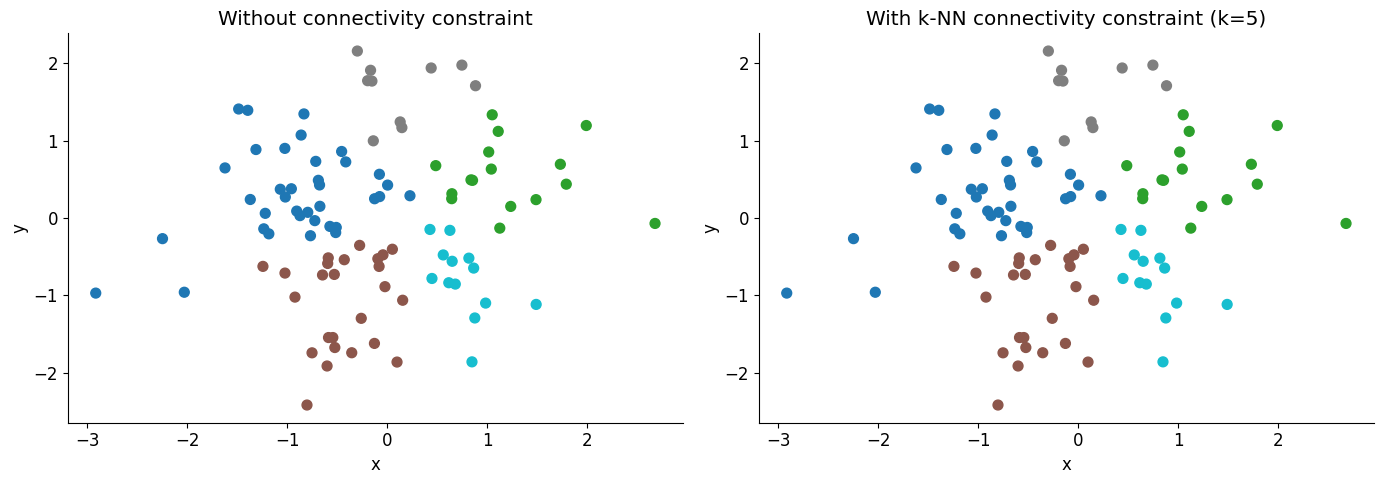

In [19]:
# Connectivity-constrained clustering on a grid

from sklearn.neighbors import kneighbors_graph

np.random.seed(3)
X_grid = np.random.randn(100, 2)

# build a connectivity graph: each point can only merge with its 5 nearest neighbours
conn = kneighbors_graph(X_grid, n_neighbors=5, include_self=False)

agg_free = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_conn = AgglomerativeClustering(n_clusters=5, linkage='ward', connectivity=conn)

labels_free = agg_free.fit_predict(X_grid)
labels_conn = agg_conn.fit_predict(X_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_grid[:, 0], X_grid[:, 1], c=labels_free, cmap='tab10', s=50)
axes[0].set_title("Without connectivity constraint")

axes[1].scatter(X_grid[:, 0], X_grid[:, 1], c=labels_conn, cmap='tab10', s=50)
axes[1].set_title("With k-NN connectivity constraint (k=5)")

for ax in axes: ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout()
plt.show()


## 11. Iris Dataset — End-to-End Pipeline

Let's run the full pipeline on the Iris dataset:  
load → scale → cluster → evaluate → visualise.


In [20]:
# Load Iris

iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names = iris.feature_names
target_names  = iris.target_names

print("Shape:", X_iris.shape)
print("Features:", feature_names)
print("Classes:", target_names)

df_iris = pd.DataFrame(X_iris, columns=feature_names)
df_iris['species'] = [target_names[y] for y in y_iris]
df_iris.head()


Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [21]:
# Scale → fit → evaluate

scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

Z_iris = linkage(X_iris_scaled, method='ward')
c_iris, _ = cophenet(Z_iris, pdist(X_iris_scaled))
print(f"Cophenetic correlation (Ward): {c_iris:.4f}")

# try K=2, 3, 4
for k in [2, 3, 4]:
    lbl = fcluster(Z_iris, t=k, criterion='maxclust')
    sil = silhouette_score(X_iris_scaled, lbl)
    ari = adjusted_rand_score(y_iris, lbl)
    print(f"K={k}  |  Silhouette={sil:.3f}  |  ARI={ari:.3f}")


Cophenetic correlation (Ward): 0.8226
K=2  |  Silhouette=0.577  |  ARI=0.544
K=3  |  Silhouette=0.447  |  ARI=0.615
K=4  |  Silhouette=0.401  |  ARI=0.588


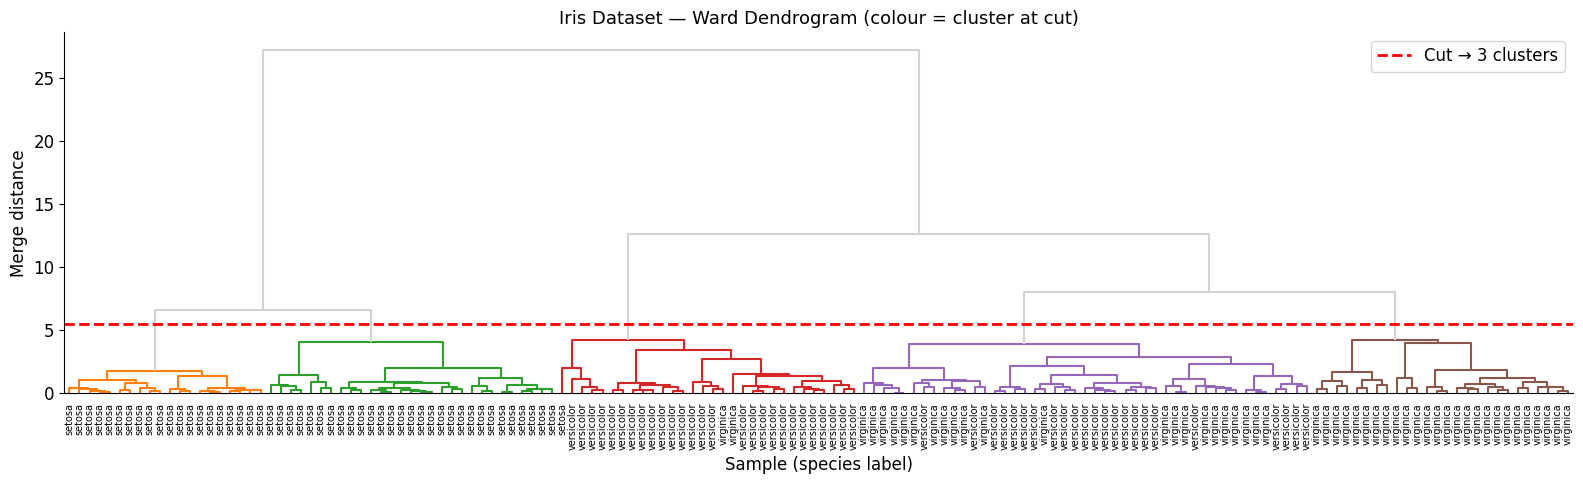

In [22]:
# Dendrogram for Iris — colour at K=3

fig, ax = plt.subplots(figsize=(16, 5))
dendrogram(Z_iris, ax=ax, color_threshold=5.5,
           above_threshold_color='lightgray',
           leaf_rotation=90, leaf_font_size=7,
           labels=[target_names[y] for y in y_iris])
ax.axhline(y=5.5, color='red', linestyle='--', lw=2, label='Cut → 3 clusters')
ax.set_title("Iris Dataset — Ward Dendrogram (colour = cluster at cut)", fontsize=13)
ax.set_xlabel("Sample (species label)")
ax.set_ylabel("Merge distance")
ax.legend()
plt.tight_layout()
plt.show()


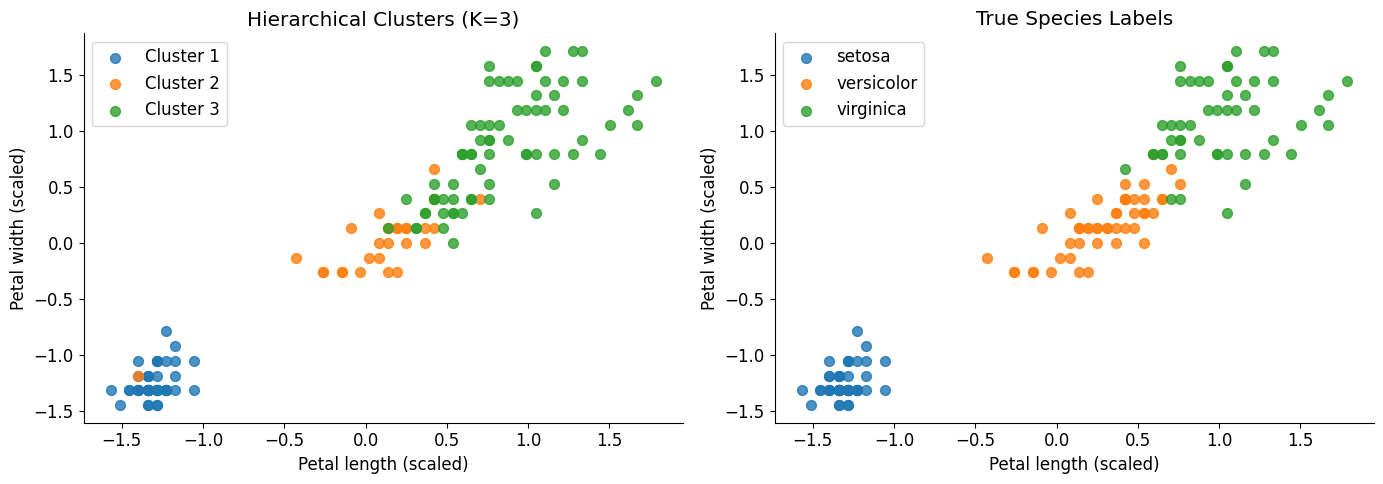

In [23]:
# Scatter matrix coloured by cluster assignment (K=3)

labels_iris = fcluster(Z_iris, t=3, criterion='maxclust')

df_plot = pd.DataFrame(X_iris_scaled, columns=['sep_len','sep_wid','pet_len','pet_wid'])
df_plot['cluster'] = labels_iris.astype(str)
df_plot['true']    = [target_names[y] for y in y_iris]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {1: 'tab:blue', 2: 'tab:orange', 3: 'tab:green'}
for lbl, grp in df_plot.groupby('cluster'):
    axes[0].scatter(grp['pet_len'], grp['pet_wid'],
                    label=f'Cluster {lbl}', s=50, alpha=0.8, c=colors[int(lbl)])
axes[0].set_title("Hierarchical Clusters (K=3)")
axes[0].set_xlabel("Petal length (scaled)")
axes[0].set_ylabel("Petal width (scaled)")
axes[0].legend()

for species, grp in df_plot.groupby('true'):
    axes[1].scatter(grp['pet_len'], grp['pet_wid'], label=species, s=50, alpha=0.8)
axes[1].set_title("True Species Labels")
axes[1].set_xlabel("Petal length (scaled)")
axes[1].set_ylabel("Petal width (scaled)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 12. Non-Spherical Data — Where Single Linkage Shines

Ward linkage assumes roughly spherical, equal-size clusters.  
For crescent / moon shapes, single linkage can follow the chain.  
Let's compare.


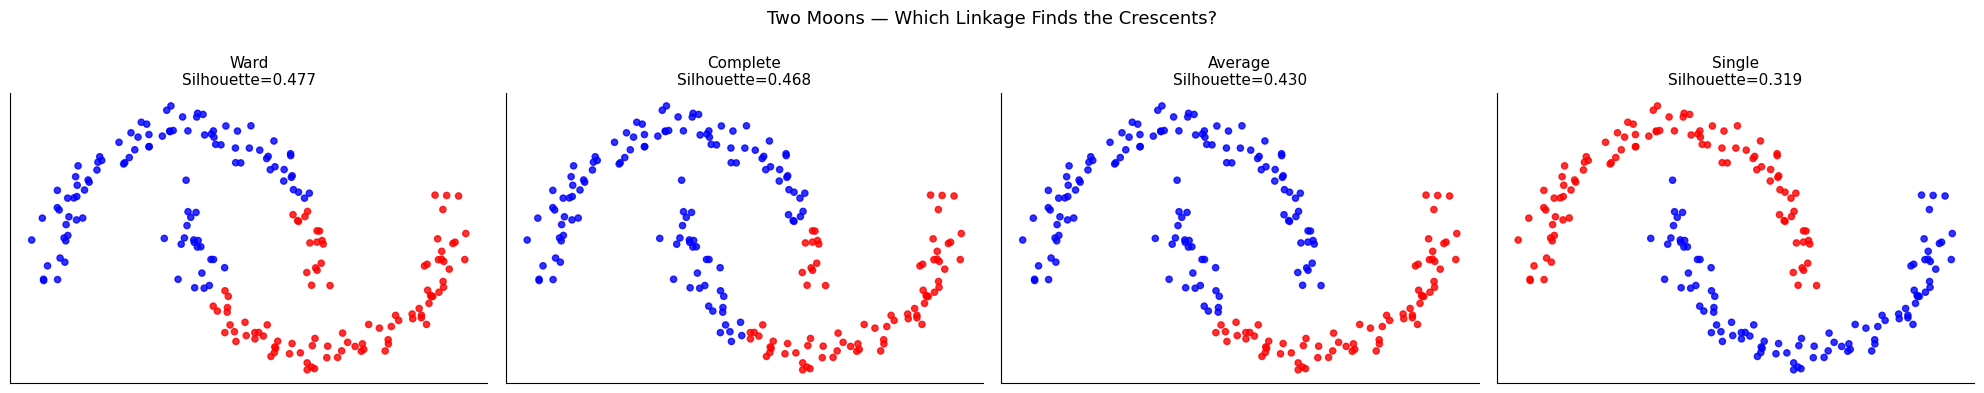

In [27]:
# Fixed moons linkage comparison plot (avoid invalid multiline string)
X_moons, y_moons = make_moons(n_samples=200, noise=0.07, random_state=42)
methods_test = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, method in zip(axes, methods_test):
    agg_m = AgglomerativeClustering(n_clusters=2, linkage=method)
    lbl_m = agg_m.fit_predict(X_moons)
    sil_m = silhouette_score(X_moons, lbl_m)
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=lbl_m, cmap='bwr', s=20, alpha=0.8)
    ax.set_title(f"{method.capitalize()}\nSilhouette={sil_m:.3f}", fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Two Moons — Which Linkage Finds the Crescents?", fontsize=13)
plt.tight_layout()
plt.show()

## 13. Customer Segmentation — Synthetic Business Case

A practical scenario: segment customers based on annual spend and visit frequency.  
This is exactly the kind of problem hierarchical clustering solves well in practice.


In [28]:
# Generate synthetic customer data

np.random.seed(99)
n_customers = 120

customers = pd.DataFrame({
    'annual_spend':    np.concatenate([
                           np.random.normal(500,  80,  40),   # occasional buyers
                           np.random.normal(2000, 200, 40),   # regular buyers
                           np.random.normal(5000, 400, 40)]), # premium buyers
    'visit_freq':      np.concatenate([
                           np.random.normal(2,  0.5, 40),
                           np.random.normal(8,  1.5, 40),
                           np.random.normal(20, 3.0, 40)]),
    'avg_basket_size': np.concatenate([
                           np.random.normal(50,  10, 40),
                           np.random.normal(150, 30, 40),
                           np.random.normal(300, 50, 40)])
})

print("Dataset shape:", customers.shape)
customers.describe().round(1)


Dataset shape: (120, 3)


,annual_spend,visit_freq,avg_basket_size
count,120.0,120.0,120.0
mean,2540.6,10.0,167.3
std,1940.6,7.8,110.2
min,310.6,0.5,30.2
25%,545.1,2.4,60.7
50%,1977.9,7.7,150.8
75%,4883.6,18.7,266.6
max,5657.9,25.0,427.4


In [29]:
# Scale → cluster → assign segment labels

X_cust = StandardScaler().fit_transform(customers)
Z_cust  = linkage(X_cust, method='ward')

# cut at K=3
cust_labels = fcluster(Z_cust, t=3, criterion='maxclust')
customers['segment'] = cust_labels

seg_names = {1: 'Occasional', 2: 'Regular', 3: 'Premium'}
customers['segment_name'] = customers['segment'].map(seg_names)

print("Silhouette score:", round(silhouette_score(X_cust, cust_labels), 4))
print()
print(customers.groupby('segment_name')[['annual_spend','visit_freq','avg_basket_size']].mean().round(1))


Silhouette score: 0.7561

              annual_spend  visit_freq  avg_basket_size
segment_name                                           
Occasional          5105.5        20.2            305.0
Premium             2015.9         7.6            143.8
Regular              500.5         2.0             53.2


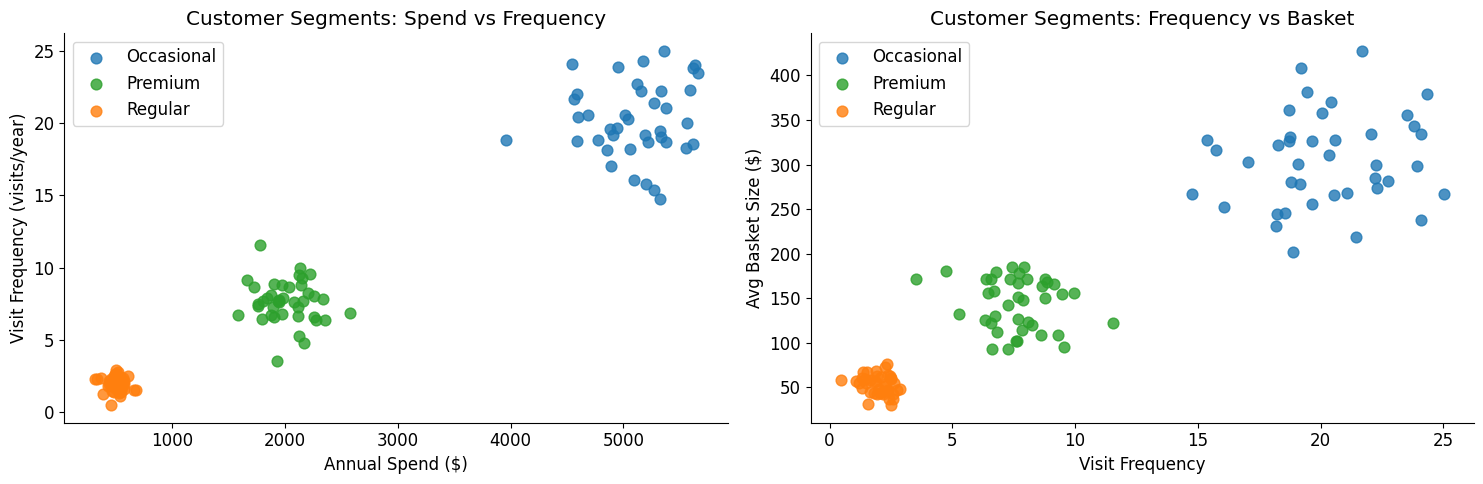

In [30]:
# Visualise customer segments

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors_map = {'Occasional':'tab:blue', 'Regular':'tab:orange', 'Premium':'tab:green'}

for seg, grp in customers.groupby('segment_name'):
    axes[0].scatter(grp['annual_spend'], grp['visit_freq'],
                    label=seg, s=60, alpha=0.8, c=colors_map[seg])
axes[0].set_xlabel("Annual Spend ($)")
axes[0].set_ylabel("Visit Frequency (visits/year)")
axes[0].set_title("Customer Segments: Spend vs Frequency")
axes[0].legend()

for seg, grp in customers.groupby('segment_name'):
    axes[1].scatter(grp['visit_freq'], grp['avg_basket_size'],
                    label=seg, s=60, alpha=0.8, c=colors_map[seg])
axes[1].set_xlabel("Visit Frequency")
axes[1].set_ylabel("Avg Basket Size ($)")
axes[1].set_title("Customer Segments: Frequency vs Basket")
axes[1].legend()

plt.tight_layout()
plt.show()


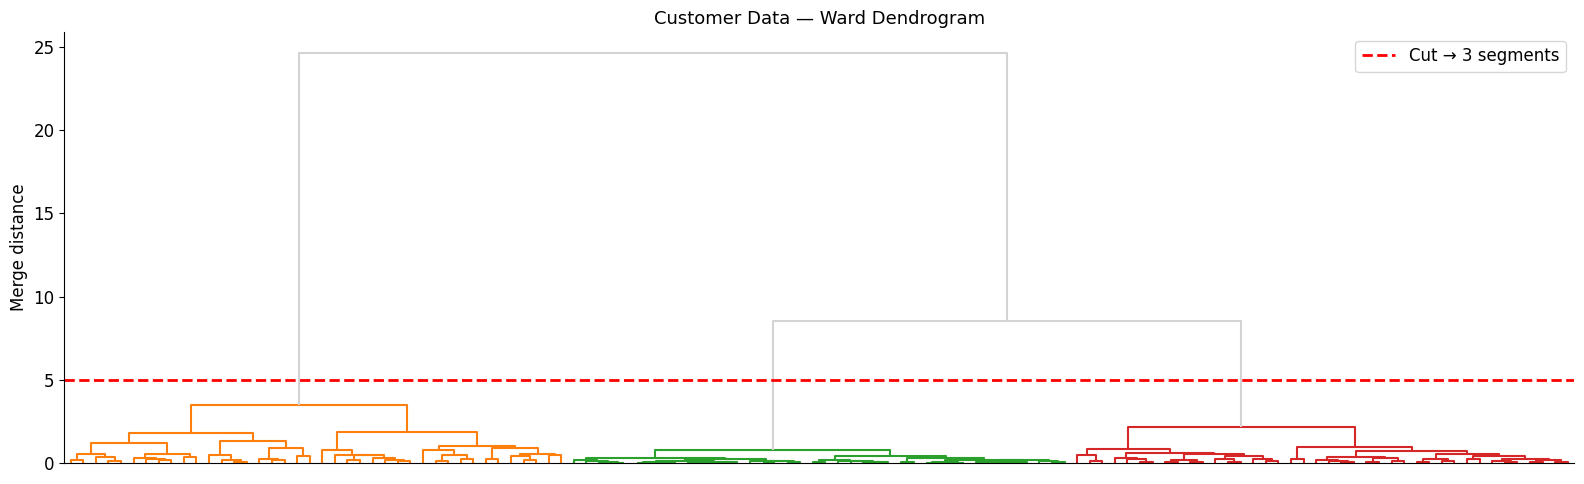

In [31]:
# Customer segment dendrogram — colour-coded

fig, ax = plt.subplots(figsize=(16, 5))
# colour leaves by true segment
leaf_colors = {i: colors_map[customers['segment_name'].iloc[i]] for i in range(n_customers)}

ddata = dendrogram(Z_cust, ax=ax, color_threshold=5.0,
                   above_threshold_color='lightgray',
                   no_labels=True)
ax.axhline(y=5.0, color='red', linestyle='--', lw=2, label='Cut → 3 segments')
ax.set_title("Customer Data — Ward Dendrogram", fontsize=13)
ax.set_ylabel("Merge distance")
ax.legend()
plt.tight_layout()
plt.show()


## 14. Evaluation Metrics Summary

| Metric | Range | Goal | Requires true labels? |
|--------|-------|------|-----------------------|
| **Silhouette Score** | −1 to +1 | Maximise | No |
| **Davies-Bouldin Index** | 0 to ∞ | Minimise | No |
| **Adjusted Rand Index** | −1 to +1 | Maximise | Yes |
| **Cophenetic Correlation** | 0 to 1 | Maximise | No |

Always use **multiple metrics** — no single score tells the full story.


In [32]:
# Full evaluation report for Iris K=3

lbl_eval = fcluster(Z_iris, t=3, criterion='maxclust')

sil  = silhouette_score(X_iris_scaled, lbl_eval)
dbi  = davies_bouldin_score(X_iris_scaled, lbl_eval)
ari  = adjusted_rand_score(y_iris, lbl_eval)
cop, _ = cophenet(Z_iris, pdist(X_iris_scaled))

print("=" * 40)
print(" Hierarchical Clustering Evaluation")
print("=" * 40)
print(f" Silhouette Score      : {sil:.4f}  (higher is better)")
print(f" Davies-Bouldin Index  : {dbi:.4f}  (lower is better)")
print(f" Adjusted Rand Index   : {ari:.4f}  (1.0 = perfect)")
print(f" Cophenetic Correlation: {cop:.4f}  (>0.75 is good)")
print("=" * 40)


 Hierarchical Clustering Evaluation
 Silhouette Score      : 0.4467  (higher is better)
 Davies-Bouldin Index  : 0.8035  (lower is better)
 Adjusted Rand Index   : 0.6153  (1.0 = perfect)
 Cophenetic Correlation: 0.8226  (>0.75 is good)


## 15. Hierarchical vs K-Means — Head to Head

| Property | Hierarchical | K-Means |
|----------|-------------|---------|
| Need to specify K | No (choose after) | Yes (before) |
| Handles non-spherical | Single linkage can | No |
| Deterministic | Yes | No (random init) |
| Complexity | O(n² log n) – O(n³) | O(nKI) |
| Memory | O(n²) distance matrix | O(nK) |
| Interpretability | Dendrogram is visual | Centroids only |
| Best for | Small–medium, unknown K | Large datasets, known K |

**Rule of thumb**: use hierarchical for exploration and interpretation (<10K samples), K-Means for scale.


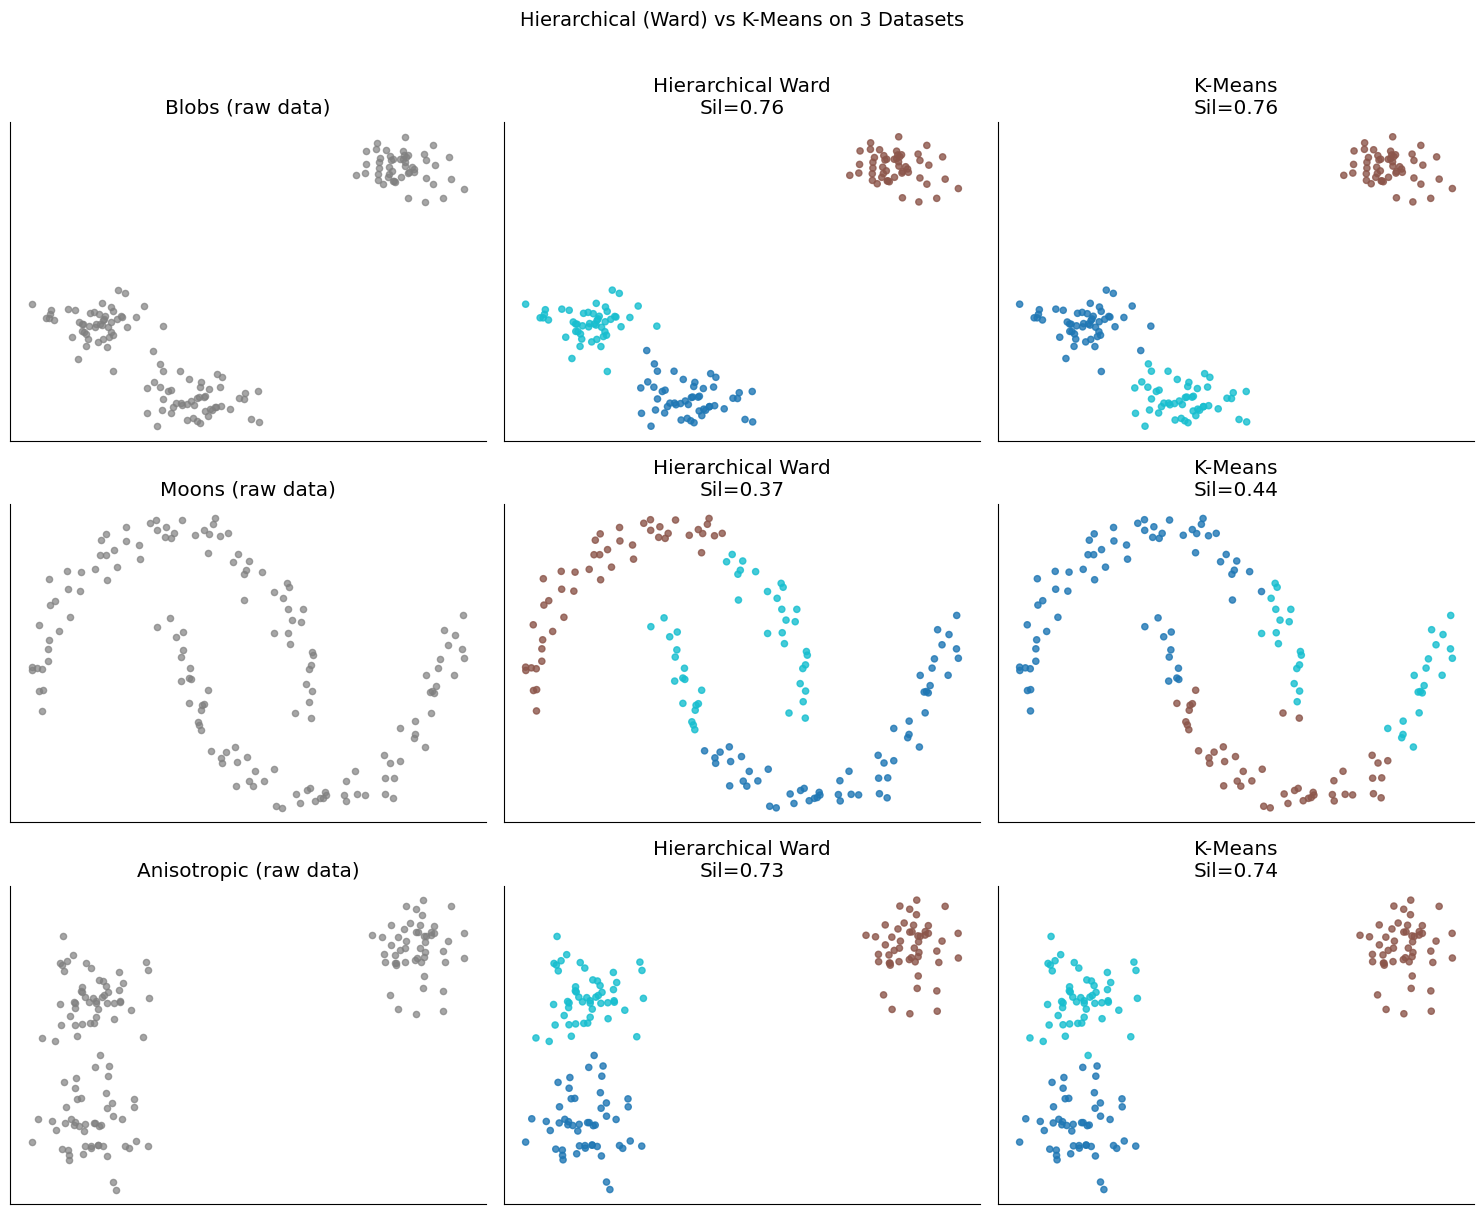

In [36]:
from sklearn.cluster import KMeans

datasets = {
    'Blobs':       make_blobs(n_samples=150, centers=3, cluster_std=0.8, random_state=1),
    'Moons':       make_moons(n_samples=150, noise=0.07, random_state=1),
    'Anisotropic': (lambda: (lambda X: (X, np.zeros(150)))(
        np.dot(make_blobs(n_samples=150, centers=3, random_state=1)[0],
               [[0.6, -0.6], [0.4, 0.8]])))()
}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
row = 0
for name, (X_d, _) in datasets.items():
    Xs = StandardScaler().fit_transform(X_d)

    axes[row][0].scatter(Xs[:, 0], Xs[:, 1], s=20, alpha=0.7, color='gray')
    axes[row][0].set_title(f"{name} (raw data)")

    lbl_h = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(Xs)
    axes[row][1].scatter(Xs[:, 0], Xs[:, 1], c=lbl_h, cmap='tab10', s=20, alpha=0.8)
    axes[row][1].set_title(f"Hierarchical Ward\nSil={silhouette_score(Xs, lbl_h):.2f}")

    lbl_k = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(Xs)
    axes[row][2].scatter(Xs[:, 0], Xs[:, 1], c=lbl_k, cmap='tab10', s=20, alpha=0.8)
    axes[row][2].set_title(f"K-Means\nSil={silhouette_score(Xs, lbl_k):.2f}")

    for ax in axes[row]:
        ax.set_xticks([])
        ax.set_yticks([])

    row += 1

plt.suptitle("Hierarchical (Ward) vs K-Means on 3 Datasets", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 16. Truncated Dendrograms for Large Datasets

When you have hundreds or thousands of points, the full dendrogram becomes unreadable.  
Use `truncate_mode='lastp'` to show only the top P merges.


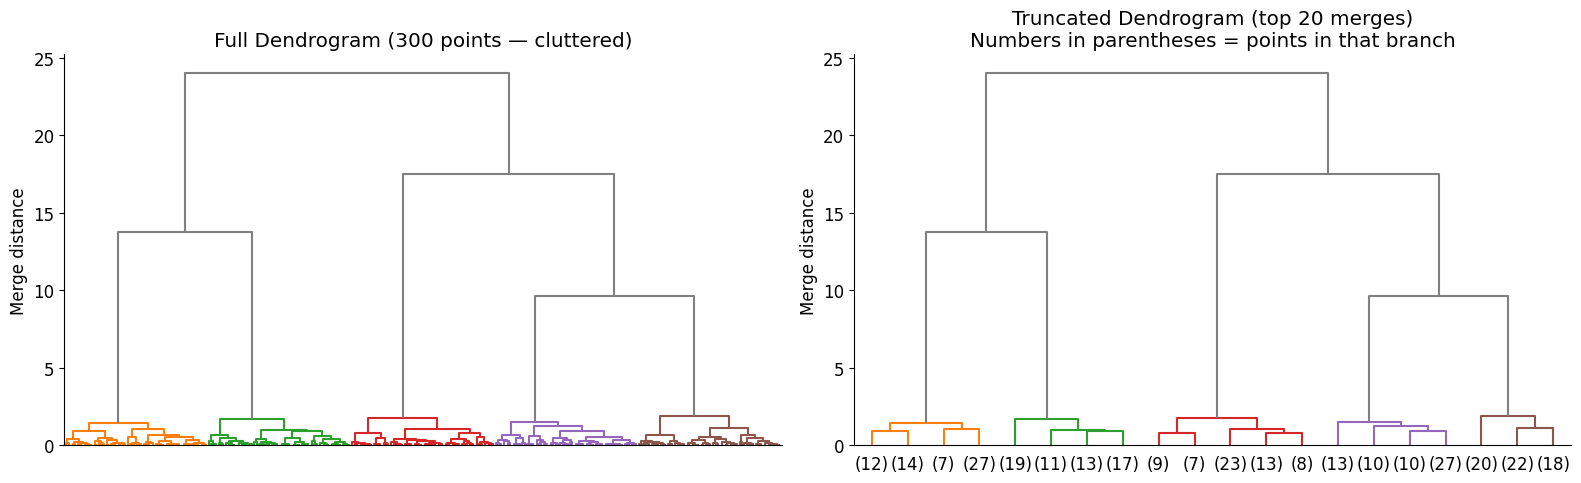

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram

# Truncated dendrogram — show only top 20 merges
np.random.seed(10)
X_large, _ = make_blobs(n_samples=300, centers=5, cluster_std=1.0)
X_large_s = StandardScaler().fit_transform(X_large)
Z_large = linkage(X_large_s, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Full dendrogram
dendrogram(Z_large, ax=axes[0], no_labels=True, color_threshold=6,
           above_threshold_color='gray')
axes[0].set_title("Full Dendrogram (300 points — cluttered)")

# Truncated dendrogram
dendrogram(Z_large, ax=axes[1], truncate_mode='lastp', p=20,
           show_leaf_counts=True, color_threshold=6,
           above_threshold_color='gray')
axes[1].set_title("Truncated Dendrogram (top 20 merges)\nNumbers in parentheses = points in that branch")

for ax in axes:
    ax.set_ylabel("Merge distance")

plt.tight_layout()
plt.show()

## 17. Heatmap + Dendrogram (clustermap)

`seaborn.clustermap` combines a hierarchical dendrogram with a heatmap.  
It simultaneously clusters both rows and columns — extremely useful for gene expression, correlation matrices, and feature analysis.


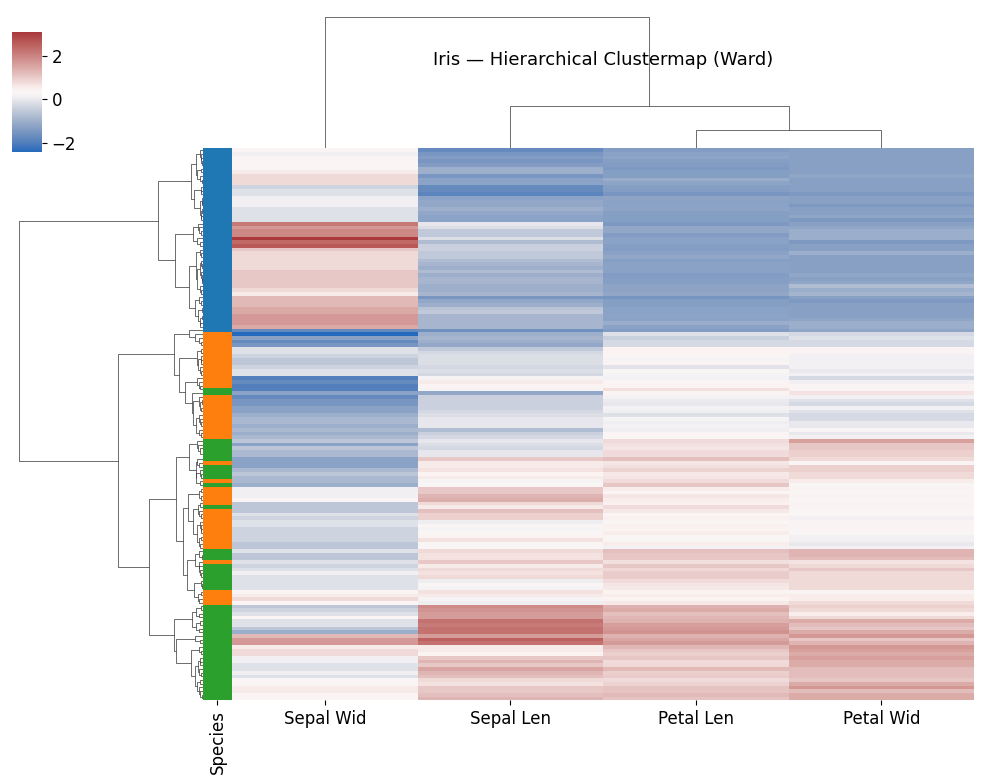

In [38]:
# seaborn clustermap — Iris features

df_heatmap = pd.DataFrame(X_iris_scaled,
                           columns=['Sepal Len','Sepal Wid','Petal Len','Petal Wid'])
df_heatmap['species'] = [target_names[y] for y in y_iris]
df_heatmap = df_heatmap.sort_values('species').drop(columns='species')

species_colors = [('tab:blue' if y==0 else 'tab:orange' if y==1 else 'tab:green')
                  for y in sorted(y_iris)]
row_colors = pd.Series(species_colors, name='Species', index=df_heatmap.index)

g = sns.clustermap(df_heatmap, method='ward', metric='euclidean',
                   cmap='vlag', figsize=(10, 8),
                   row_colors=row_colors, yticklabels=False,
                   cbar_pos=(0.02, 0.8, 0.03, 0.15))
g.ax_heatmap.set_title("Iris — Hierarchical Clustermap (Ward)", pad=60, fontsize=13)
plt.show()


## 18. Practical Tips & Common Pitfalls

### Always Do This
- **Scale your features** before clustering — unscaled features let one variable dominate the distance
- **Start with Ward linkage** — it almost always outperforms single/complete on tabular data
- **Check cophenetic correlation** — if it's below 0.75, try a different linkage or metric
- **Use multiple K evaluation metrics** — silhouette + Davies-Bouldin + domain knowledge

### Pitfalls to Avoid
- **Single linkage chaining**: single linkage tends to chain long stringy clusters on compact data
- **Outliers break complete linkage**: one extreme outlier forces every cluster to stretch to include it
- **Don't trust silhouette alone**: a score of 0.5 on one dataset can mean something very different on another
- **Dendrogram colour is not automatic**: you must set `color_threshold` — the default may mislead you

### When NOT to Use Hierarchical Clustering
- Dataset > 50K rows → use mini-batch K-Means or HDBSCAN instead
- You need online/streaming updates → hierarchical is batch-only
- You need guaranteed spherical clusters with known K → K-Means is faster and simpler


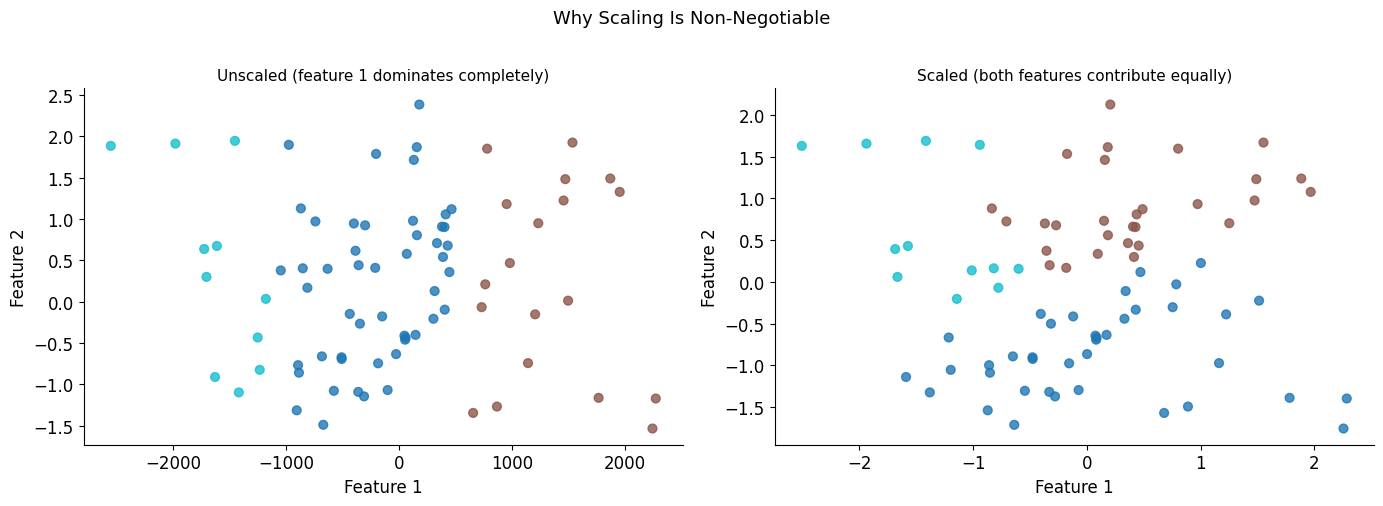

In [39]:
# Scaling matters — side-by-side proof

np.random.seed(0)
X_unscaled = np.column_stack([
    np.random.randn(80) * 1000,    # feature 1: range ~±3000
    np.random.randn(80) * 1        # feature 2: range ~±3
])
X_scaled_demo = StandardScaler().fit_transform(X_unscaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, X_use, title in zip(axes,
    [X_unscaled, X_scaled_demo],
    ['Unscaled (feature 1 dominates completely)', 'Scaled (both features contribute equally)']):
    lbl = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X_use)
    ax.scatter(X_use[:,0], X_use[:,1], c=lbl, cmap='tab10', s=40, alpha=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")

plt.suptitle("Why Scaling Is Non-Negotiable", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [40]:
# Final recap table

summary = pd.DataFrame({
    'Linkage'   : ['Single', 'Complete', 'Average', 'Ward'],
    'Metric'    : ['Min pair dist', 'Max pair dist', 'Mean pair dist', 'Min variance increase'],
    'Cluster Shape' : ['Elongated/chains', 'Compact, spherical', 'Intermediate', 'Compact, equal-size'],
    'Sensitive to Outliers' : ['Very sensitive', 'Very sensitive', 'Moderate', 'Low'],
    'Best Use Case' : ['Non-convex shapes', 'Well-separated blobs', 'General purpose', 'Most tabular data']
})
summary.set_index('Linkage')


,Metric,Cluster Shape,Sensitive to Outliers,Best Use Case
Linkage,,,,
Single,Min pair dist,Elongated/chains,Very sensitive,Non-convex shapes
Complete,Max pair dist,"Compact, spherical",Very sensitive,Well-separated blobs
Average,Mean pair dist,Intermediate,Moderate,General purpose
Ward,Min variance increase,"Compact, equal-size",Low,Most tabular data


## Summary

You now have everything you need to apply hierarchical clustering in practice:

1. **Algorithm**: agglomerative bottom-up merging — no K required upfront
2. **Linkage**: Ward for compact clusters, single for non-convex shapes
3. **Dendrogram**: cut at the largest vertical gap; use silhouette to validate K
4. **Distance metric**: Euclidean + Ward is the default; cosine for text/high-dim
5. **Evaluation**: cophenetic correlation for fit, silhouette + DBI for quality, ARI if you have labels
6. **Scale first** — always
7. **Use sklearn** for production pipelines; **scipy** for dendrograms and fine control

The dendrogram is the unique advantage of this algorithm — it gives you a complete picture of your data's cluster structure at every resolution simultaneously.
